## Importando as bibliotecas

In [504]:
# pandas - para a análise e manipulação das bases de dados
import pandas as pd

# numpy - suporte em alguns calculos envolvendo as tabelas
import numpy as np

# matplotlib - para plotting dos gráficos
import matplotlib.pyplot as plt 

# sklearn - para a criação do modelo preditivo
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

# sklearn - para métricas dos modelos 
from sklearn.metrics import roc_auc_score, brier_score_loss, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

## Carregando as tabelas 

In [505]:
df_cadastral = pd.read_csv('data/base_cadastral.csv', sep= ';')
df_info = pd.read_csv('data/base_info.csv', sep= ';')
df_pagamentos_desenv = pd.read_csv('data/base_pagamentos_desenvolvimento.csv', sep= ';')
df_pagamentos_teste = pd.read_csv('data/base_pagamentos_teste.csv', sep= ';')

## Visualização das Tabelas

### `df_cadastral` - Base Cadastral

Dados fixos do cliente.

In [506]:
df_cadastral.head()

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


In [507]:
df_cadastral.shape

(1315, 8)

In [508]:
df_cadastral.info()

<class 'pandas.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID_CLIENTE           1315 non-null   int64
 1   DATA_CADASTRO        1315 non-null   str  
 2   DDD                  1078 non-null   str  
 3   FLAG_PF              66 non-null     str  
 4   SEGMENTO_INDUSTRIAL  1232 non-null   str  
 5   DOMINIO_EMAIL        1285 non-null   str  
 6   PORTE                1274 non-null   str  
 7   CEP_2_DIG            1315 non-null   str  
dtypes: int64(1), str(7)
memory usage: 82.3 KB


In [509]:
df_cadastral.isnull().sum()

ID_CLIENTE                0
DATA_CADASTRO             0
DDD                     237
FLAG_PF                1249
SEGMENTO_INDUSTRIAL      83
DOMINIO_EMAIL            30
PORTE                    41
CEP_2_DIG                 0
dtype: int64

### `df_info` - Base Info

Dados mensais do cliente.

In [510]:
df_info.head()

,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


In [511]:
df_info.shape

(24401, 4)

In [512]:
df_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  str    
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 762.7 KB


In [513]:
df_info.isnull().sum()

ID_CLIENTE               0
SAFRA_REF                0
RENDA_MES_ANTERIOR     717
NO_FUNCIONARIOS       1252
dtype: int64

### `df_pagamentos_desenv` - Base de Pagamentos Desenvolvimento

Histórico de cobranças já pagas. Será a base utilizada para ensinar  o modelo preditivo.

In [514]:
df_pagamentos_desenv.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


In [515]:
df_pagamentos_desenv.shape

(77414, 7)

In [516]:
df_pagamentos_desenv.info()

<class 'pandas.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  str    
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  str    
 3   DATA_PAGAMENTO          77414 non-null  str    
 4   DATA_VENCIMENTO         77414 non-null  str    
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 4.1 MB


In [517]:
df_pagamentos_desenv.isnull().sum()

ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1170
TAXA                         0
dtype: int64

### `df_pagamentos_teste` - Base de Pagamentos Teste

Histórico de cobranças recentes do cliente, que ainda estão em aberto. Base que será utilizada para o teste final do modelo preditivo. 

In [518]:
df_pagamentos_teste.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [519]:
df_pagamentos_teste.shape

(12275, 6)

In [520]:
df_pagamentos_teste.info()

<class 'pandas.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  str    
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  str    
 3   DATA_VENCIMENTO         12275 non-null  str    
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 575.5 KB


In [521]:
df_pagamentos_teste.isnull().sum()

ID_CLIENTE                  0
SAFRA_REF                   0
DATA_EMISSAO_DOCUMENTO      0
DATA_VENCIMENTO             0
VALOR_A_PAGAR             131
TAXA                        0
dtype: int64

## Construindo o target

Como será criado um modelo preditivo baseado em **aprendizado supervisionado**, é preciso definir outra variável além das *features* para que seja possível treinar o modelo sob a ótica do seguinte problema: **Problema de classificação binária com saída probabilística**

Isso acontece pois as *features* (X) irão ser representadas pelas colunas das tabelas que o modelo levará em consideração para realizar a predição (`VALOR_A_PAGAR`,`PORTE`,`PRAZO_DIAS`, histórico do cliente, etc). Enquanto isso, haverá uma variável (i.e. coluna) *target* que será construída e irá representar a *label* (rótulo y), ou seja, a "resposta certa do gabarito".

Dessa forma, o modelo irá aprender pegando uma parte do conjunto de dados e treinando com a "resposta pronta".

A variável *target* será construída utilizando como base a regra de negócio estabelecida para determinar os clientes que estão com o pagamento inadimplente:

- **Pagamento Inadimplente**: realizado com **5 dias ou mais de atraso** com relação à `DATA_VENCIMENTO`.

A construção da variável será feita utilizando `df_pagamentos_desenv`, já que é a única base que contém a `DATA_PAGAMENTO`, como já mencionado no enunciado do *case*.

---

**Passos a serem executados nessa etapa**:

1. Converter as colunas de datas dos *Dataframes* para `datetime`
2. Calcular o atraso do pagamento em dias (`DATA_PAGAMENTO` - `DATA_VENCIMENTO`)
3. Criar a variável `TARGET` binária (1 = inadimplente, 0 = adimplente)
4. Verificar a distribuição de `TARGET`
5. Verificar a consistência das datas de prazo de empréstimo

### 1. Convertendo as colunas dos Dataframes para `datetime`

Primeiramente, as colunas das bases de dados serão convertidas para o formato `datetime` para que a biblioteca do pandas consiga "enxergar" realmente as datas ao invés de *strings*. 

Dessa forma, será possível realizar operações, fazer comparações e extrair pontos específicos das datas (como meses, dias, anos separadamente). 

In [522]:
date_cols = ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']
df_pagamentos_desenv[date_cols] = df_pagamentos_desenv[date_cols].apply(pd.to_datetime)

df_pagamentos_desenv[date_cols].describe()

,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO
count,77414,77414,77414
mean,2020-02-02 21:01:42.400082,2020-02-26 00:36:28.627379,2020-02-26 04:43:20.087839
min,2018-08-17 00:00:00,2018-06-19 00:00:00,2017-11-27 00:00:00
25%,2019-05-21 00:00:00,2019-06-13 00:00:00,2019-06-13 00:00:00
50%,2020-01-27 00:00:00,2020-02-19 00:00:00,2020-02-18 00:00:00
75%,2020-10-27 00:00:00,2020-11-18 00:00:00,2020-11-18 00:00:00
max,2021-06-30 00:00:00,2021-11-24 00:00:00,2027-03-31 00:00:00


### 2. & 3. Calcular o atraso do pagamento + `TARGET`

Em seguida, será definido o atraso do pagamento onde:

- *Valores positivos*: Indica que o cliente pagou depois do vencimento 
- *Valores negativos/zeros*: Indica que o cliente pagou no dia ou adiantado

`ATRASO_DIAS` será a coluna que indicará a quantidade de dias de atraso do cliente.

Dessa forma, é possível definir a coluna `TARGET` a partir da regra de negócio:

- *Inadimplente*: atraso >= 5 dias


In [523]:
# Atraso em dias
df_pagamentos_desenv['ATRASO_DIAS'] = (
    df_pagamentos_desenv['DATA_PAGAMENTO'] - df_pagamentos_desenv['DATA_VENCIMENTO']
).dt.days

# Regra de negócio
df_pagamentos_desenv['TARGET'] = (df_pagamentos_desenv['ATRASO_DIAS'] >= 5).astype(int) 

In [524]:
df_pagamentos_desenv[['DATA_VENCIMENTO','DATA_PAGAMENTO','ATRASO_DIAS','TARGET']].head()

,DATA_VENCIMENTO,DATA_PAGAMENTO,ATRASO_DIAS,TARGET
0,2018-09-06,2018-09-06,0,0
1,2018-09-10,2018-09-11,1,0
2,2018-09-17,2018-09-18,1,0
3,2018-10-05,2018-10-11,6,1
4,2018-09-20,2018-09-20,0,0


Observe que a variável `TARGET` será uma variável binária:

- *1*: Indica clientes que tiveram um atraso maior ou igual à 5
- *0*: Indica clientes que tiveram um atraso menor do que 5 ou que pagaram no dia ou com antecedência.

### 4. Verificando a distribuição do `TARGET`

Entender como se comporta a distribuição entre as duas classes da variável `TARGET`será importante para determinar o contexto da regra de negócio juntamente com as métricas que podem ser aplicadas para a avaliação do modelo que será construído.

In [525]:
# Distribuição da coluna target
target_dist = df_pagamentos_desenv['TARGET'].value_counts(normalize= True).rename('proporcao') #normalize= true -> frequência relativa
print(target_dist)

TARGET
0    0.92978
1    0.07022
Name: proporcao, dtype: float64


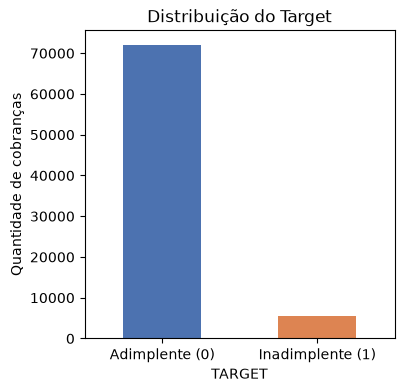

In [526]:
# Visualizando a distribuição
fig, ax = plt.subplots(figsize= (4,4))
df_pagamentos_desenv['TARGET'].value_counts().sort_index().plot(
    kind= 'bar', ax= ax, color= ['#4C72B0','#DD8452']
)

ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'], rotation= 0)
ax.set_title('Distribuição do Target')
ax.set_ylabel('Quantidade de cobranças')
plt.show()

Com relação a distribuição da coluna de *target*, é possível visualizar que a distribuição ficou **claramente desbalanceada** (aproximadamente 93% adimplente e aproximadamente 7% inadimplente).

Como geralmente, os casos de inadimplência costumam serem mais raros, isso resulta na decisão de avaliar o futuro modelo em métricas como **ROC-AUC** e **BrieScore**, em vez de acurácia.

Isso acontece pois, caso a acurácia adotada como métrica, ela não iria levar em consideração a distribuição não-uniforme do modelo. Sendo esta uma métrica que poderia enganar e distorcer futuras interpretações sobre a perfomace do modelo. 

### 5. Verificando a consistência das datas de prazo de empréstimo

O intuito desta checagem é confirmar se as datas fazem sentido referente ao prazo de empréstimo (i.e. `DATA_VENCIMENTO`-`DATA_EMISSAO_DOCUMENTO`), chegando a sua respectiva distribuição. 

É importante realizar essa verificação cedo pois, posteriormente, essa variável poderá servir como *feature* na etapa de Engenharia de Variáveis.

- `PRAZO_DIAS`representa a quantidade de dias de prazo que o cliente teve, desde a criação da cobrança em `DATA_EMISSAO_DOCUMENTO` até o dia em que ela venceu `DATA_VENCIMENTO`

Ondes:

**Os valores positivos** (`DATA_VENCIMENTO`>`DATA_EMISSAO_DOCUMENTO`) indicam que a cobrança foi criada e que posteriormente foi vencida [*caso típico*]. 

**Os valores negativos ou zero** indicam casos estranhos e fora da interpretação de negócio, pois:

`DATA_VENCIMENTO` = `DATA_EMISSAO_DOCUMENTO`: A cobrança foi à vista, ou seja, no mesmo dia que abriu foi o mesmo dia. [caso atípico]
`DATA_VENCIMENTO` < `DATA_EMISSAO_DOCUMENTO`: O vencimento aconteceu antes da cobrança. [caso suspeito/surreal]

In [527]:
df_pagamentos_desenv['PRAZO_DIAS'] = (
    df_pagamentos_desenv['DATA_VENCIMENTO'] - df_pagamentos_desenv['DATA_EMISSAO_DOCUMENTO']
).dt.days

df_pagamentos_desenv['PRAZO_DIAS'].describe()

count    77414.000000
mean        23.320575
std         26.137018
min       -420.000000
25%         16.000000
50%         18.000000
75%         24.000000
max       2677.000000
Name: PRAZO_DIAS, dtype: float64

A mediana de 18 dias, 75% das cobranças com até 24 dias -> indica que o prazo típico é curto. Isso torna prazos de centenas ou milhares de dias implausíveis (outliers). 

Essas datas *supostamente* implausíveis com **prazos acima de 365 dias** serão sinalizadas e contabilizadas por meio de uma *flag*, sem serem removidas ainda, para que futuramente, haja um tratamento na etapa de `Engenharia de Variáveis` (seja para descartar, corrigir ou manter).


In [528]:
df_pagamentos_desenv['FLAG_DATA_SUSPEITA'] = df_pagamentos_desenv['PRAZO_DIAS'] > 365

n_suspeitos = df_pagamentos_desenv['FLAG_DATA_SUSPEITA'].sum()

print(f"Cobranças sinalizadas como suspeitas: {n_suspeitos} de {len(df_pagamentos_desenv)}.")
print(f"\n({n_suspeitos / len(df_pagamentos_desenv):.2%})")

df_pagamentos_desenv[df_pagamentos_desenv['FLAG_DATA_SUSPEITA']][
    ['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'PRAZO_DIAS', 'ATRASO_DIAS', 'TARGET']
].sort_values('PRAZO_DIAS', ascending=False)

Cobranças sinalizadas como suspeitas: 27 de 77414.

(0.03%)


,ID_CLIENTE,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,DATA_PAGAMENTO,PRAZO_DIAS,ATRASO_DIAS,TARGET
33271,3829967475074118757,2019-12-01,2027-03-31,2019-12-17,2677,-2661,0
34543,1097345589386012260,2019-11-20,2025-08-27,2019-12-27,2107,-2070,0
5166,8724731934863284019,2018-11-04,2024-01-28,2018-11-19,1911,-1896,0
5167,8724731934863284019,2018-11-04,2024-01-28,2018-11-19,1911,-1896,0
70244,8535586342375301953,2021-03-23,2024-10-31,2021-04-13,1318,-1297,0
70245,8535586342375301953,2021-03-23,2024-10-31,2021-04-07,1318,-1303,0
36899,1118514612547157551,2019-12-29,2023-08-03,2020-01-27,1313,-1284,0
66292,6784879562354696650,2021-02-02,2024-06-30,2021-02-17,1244,-1229,0
66293,6784879562354696650,2021-02-02,2024-06-30,2021-02-22,1244,-1224,0
52796,3204108603682323936,2020-08-19,2023-11-30,2020-09-03,1198,-1183,0


In [529]:
df_pagamentos_desenv['FLAG_DATA_SUSPEITA'].sum()

np.int64(27)

Esses registros serão mantidos na base (apenas sinalizados via `FLAG_DATA_SUSPEITA`), pois são poucos e removê-los prematuramente, antes de entender seu impacto na modelagem, seria uma decisão precipitada. Essa *flag* será retornada na seção de `Engenharia de Variáveis` para decidir seu tratamento final.

## EDA - Análise Exploratória dos Dados 

O intuito desta análise será para explorar os dados de `df_pagamentos_desenv`. O foco é descobrir quais variáveis (i.e. colunas) que parecem se relacionar com a inadimplência (`TARGET`|y), ou seja, **definir as features (X) do modelo**.

---

A exploração se deu da seguinte forma: 

1. Variáveis numéricas da própria base de pagamentos (`VALOR_A_PAGAR`,`TAXA`,`PRAZO_DIAS`)
2. Comportamento no tempo (por `SAFRA_REF`)
3. Relação de `TARGET` com variáveis dos *dataframes* `df_cadastral` e `df_info`
4. Cruzamento exploratório com `df_cadastral` e `df_info`
5. Analisar a taxa de inadimplência por `PORTE`, `SEGMENTO_INDUSTRIAL` e `FLAG_PF`
6. Analisar a correlação do `TARGET` com as colunas numéricas
7. Analisar a tabela de quartis da variável `VALOR A PAGAR`

### 1. Variáveis numéricas da base de pagamentos 

O intuito é verificar as colunas numéricas carregam informações de `df_pagamentos_desenv`

In [530]:
num_cols = ['VALOR_A_PAGAR','TAXA', 'PRAZO_DIAS', 'ATRASO_DIAS']
df_pagamentos_desenv[num_cols].describe()

,VALOR_A_PAGAR,TAXA,PRAZO_DIAS,ATRASO_DIAS
count,7.624400e+04,77414.000000,77414.000000,77414.000000
mean,4.659078e+04,6.789623,23.320575,-0.171429
std,4.643393e+04,1.798225,26.137018,25.229477
min,1.000000e-01,4.990000,-420.000000,-2661.000000
25%,1.876536e+04,5.990000,16.000000,0.000000
50%,3.475869e+04,5.990000,18.000000,0.000000
75%,6.093384e+04,6.990000,24.000000,0.000000
max,4.400000e+06,11.990000,2677.000000,869.000000


Text(0.5, 1.0, 'PRAZO_DIAS (recortado entre -30 e 60 dias p/ visualização)')

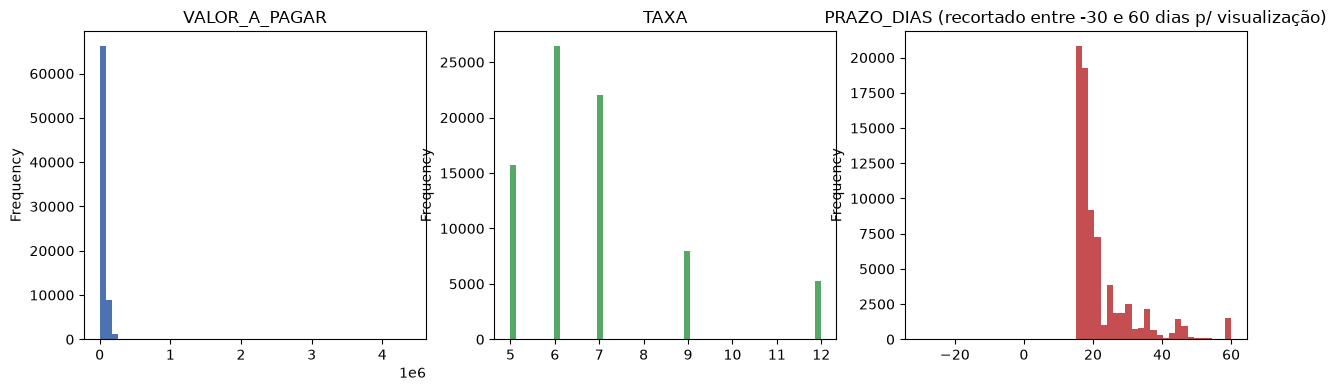

In [531]:
fig, axes = plt.subplots(1,3, figsize= (15,4))

df_pagamentos_desenv['VALOR_A_PAGAR'].plot(kind='hist', bins= 50, ax= axes[0], color= '#4C72B0')
axes[0].set_title('VALOR_A_PAGAR')

df_pagamentos_desenv['TAXA'].plot(kind='hist', bins= 50, ax= axes[1], color= '#55A868')
axes[1].set_title('TAXA')

df_pagamentos_desenv['PRAZO_DIAS'].clip(lower= -30, upper= 60).plot(kind= 'hist', bins= 50, ax= axes[2], color= '#C44E52')
axes[2].set_title('PRAZO_DIAS (recortado entre -30 e 60 dias p/ visualização)')

É possível visualizar que `PRAZO_DIAS`concentra a maioria das cobranças entre ~18 e ~25 dias, o que é coerente com um produto de crédito de curto prazo. Isso reforça o fato de que a variável `FLAG_DATA_SUSPEITA` que carrega cobranças com valores acima de 1 ano (365 dias) correspondem à *outliers*.

### 2. Prazos negativos (vencimento da cobrança anterior à sua emissão)

É possível visualizar que a variável `PRAZO_DIAS` tem valor mínimo negativo. Esses valores negativos representam cobranças em que `DATA_VENCIMENTO` é anterior à `DATA_EMISSAO_DOCUMENTO`, o que também não faz sentido de negócio.

In [532]:
prazo_negativo = df_pagamentos_desenv['PRAZO_DIAS'] < 0 
n_neg = prazo_negativo.sum()
print(f'Cobranças com PRAZO_DIAS negativo: {n_neg} ({n_neg/len(df_pagamentos_desenv):.3%})')

df_pagamentos_desenv.loc[prazo_negativo, ['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO']]

Cobranças com PRAZO_DIAS negativo: 27 (0.035%)


,ID_CLIENTE,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,DATA_PAGAMENTO
1099,1118514612547157551,2018-09-02,2018-08-27,2018-09-19
1100,1118514612547157551,2018-09-02,2018-06-20,2018-09-18
1101,1118514612547157551,2018-09-02,2018-07-25,2018-09-19
1944,1977574645216036803,2018-09-13,2018-08-31,2018-09-28
2565,8198518259946944874,2018-10-12,2017-11-27,2019-05-22
5009,6020593949794792044,2018-11-06,2018-11-05,2021-03-23
5481,8198518259946944874,2018-11-13,2017-12-28,2018-06-19
8379,8348574220426911086,2019-01-03,2018-12-17,2019-01-16
16200,4442205629227031623,2019-03-24,2018-12-07,2019-06-12
16201,4442205629227031623,2019-03-24,2018-12-07,2019-06-14


**Os casos suspeitos de prazos negativos** serão marcados e também adicionados com a *flag* já criada de data suspeita `FLAG_DATA_SUSPEITA`. Juntos, esses casos representam menos de 0.1 % da base de dados coletada dos *dataframes*.

O tratamento definitivo ficará na etapa de Engenharia de Variáveis, logo após a avaliação do cruzamento com as demais bases.

In [533]:
df_pagamentos_desenv['FLAG_DATA_SUSPEITA'] = (
    df_pagamentos_desenv['FLAG_DATA_SUSPEITA'] | prazo_negativo
)

df_pagamentos_desenv['FLAG_DATA_SUSPEITA'].sum()

np.int64(54)

### 3. Comportamento de Inadimplencia ao longo do tempo (`SAFRA_REF`)

Será feito um **split temporal** no conjunto de dados para treinar o modelo em safras mais antigas e validar as mais recentes. Ou seja, a divisão do conjunto de dados para o treino e validação do modelo preditivo será feita respeitando a ordem cronológica das datas de cobrança dos clientes, uma vez que o objetivo é treinar o modelo baseado em dados no passado para realizar a predição em datas posteriores.

Para isso, é importante entender se a taxa de inadimplência é estável ao longo do tempo ou se existe alguma tendência/sazonalidade em intervalos de tempo específicos. 

In [534]:
taxa_por_safra = df_pagamentos_desenv.groupby('SAFRA_REF')['TARGET'].agg(['mean','count'])
taxa_por_safra.columns = ['TAXA_INADIMPLENCIA', 'QTD_COBRANCAS']
taxa_por_safra

,TAXA_INADIMPLENCIA,QTD_COBRANCAS
SAFRA_REF,,
2018-08,0.061492,992
2018-09,0.048193,1992
2018-10,0.057729,2096
2018-11,0.056079,2122
2018-12,0.060709,2059
2019-01,0.051327,2299
2019-02,0.073059,1971
2019-03,0.061415,2247
2019-04,0.073372,2058


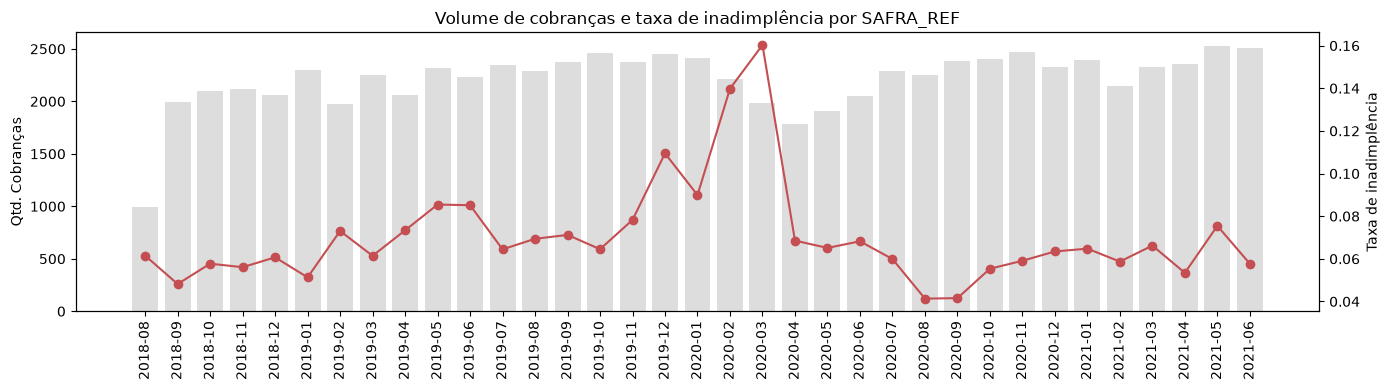

In [535]:
fig, ax1 = plt.subplots(figsize= (14,4))

ax1.bar(taxa_por_safra.index, taxa_por_safra['QTD_COBRANCAS'], color= '#DDDDDD', label= 'Qtd. Cobranças')
ax1.set_ylabel('Qtd. Cobranças')
ax1.tick_params(axis= 'x', rotation= 90)

ax2 = ax1.twinx()
ax2.plot(taxa_por_safra.index, taxa_por_safra['TAXA_INADIMPLENCIA'], color='#C44E52', marker='o', label='Taxa de inadimplência')
ax2.set_ylabel('Taxa de inadimplência')

plt.title('Volume de cobranças e taxa de inadimplência por SAFRA_REF')
fig.tight_layout()
plt.show()

Como podemos visualizar pelo gráfico, taxa de inadimplência oscila mês a mês e possui uma tendência explosiva de alta entre os meses de fevereiro e março de 2020, indo à quase 16%. Isso indica um aumento de mais do dobro do valor médio da taxa de mês a mês entre os anos de 2018 e 2021.

- **Hipótese da alta da taxa de inadimplência -> pandemia**

Durante a época da pandemia do COVID-19, com as instauração do período de quarentena, o isolamento dos colaboradores e os demais percalços para gerir negócios nesse período resultaram em uma dificuldade financeira generalizada (e em graus diferentes) nas empresas.

A explosão da taxa de inadimplência ocorrendo no começo de 2020 pode refletir justamente no período onde começou a quarentena, onde a maioria das empresas não estavam preparadas para lidar com esse cenário e, consequentemente, ocorreu um aumento considerativo na taxa de inadimplência. 

---

Por mais que tenha acontecido um variação considerável entre os anos de 2018 e 2021, **a taxa de inadimplênica oscilou entre um intervalo de aproximadamente 8% e 4%**. Isso sugere que um modelo treinado em safras mais antigas possa ser capaz de generalizar razoávelmente as safras mais recentes.

Além disso, podemos notar pelas bordas da janela de dados que as primeiras e últimas safras registradas pelas datas possuem poucas cobranças, o que merece atenção para definir o corte exato do split treino/validação. 

### 4. Cruzamento exploratório com `df_cadastral` e `df_info`

O objetivo desse cruzamento exploratório será para investigar a relação do `TARGET` com variáveis cadastrais e financeiras do cliente, juntando as tabelas de `df_cadastral` e `df_info`. Especificamente, juntando as linhas das bases diferentes que compartilham as seguintes chaves de junção em comum para cada base de dados: 

- `df_cadastral` =  `ID_CLIENTE`
- `df_info` =  `ID_CLIENTE` e `SAFRA_REF`

Juntando as variáveis de `df_cadastral` e `df_info`, é possível explorar os dados de variáveis que são importantes para a predição do modelo, mas que não estão em `df_pagamentos_desenv`. É possível citar como exemplo:

- `PORTE`, `SEGMENTO_INDUSTRIAL` por parte de `df_cadastral`
- `RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS` por parte de `df_info` 

---

- **Objetivo do merge da EDA**:

Esse *merge* exploratório (`df_eda`) será utilizado apenas para essa análise, **explorando as relações de outras variáveis com a variável `TARGET`**, não sendo usada em nenhuma das etapas posteriores. Ou seja, tratasse de um cruzamento que só serve para responder perguntas exploratórias.

- **Objetivo do merge definitivo**:

Esse *merge* será definitivo que irá servir para treinar o modelo. Esse *merge* será construído apenas na próxima seção (`Cruzamento das Bases`).


In [536]:
df_eda = (
    df_pagamentos_desenv
    .merge(df_cadastral, on= 'ID_CLIENTE', how= 'left')
    .merge(df_info, on= ['ID_CLIENTE', 'SAFRA_REF'], how= 'left')
)

df_eda.shape

(77414, 20)

In [537]:
df_eda.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,ATRASO_DIAS,TARGET,PRAZO_DIAS,FLAG_DATA_SUSPEITA,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,0,20,False,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,1,0,22,False,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,1,0,22,False,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,6,1,36,False,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,0,20,False,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN


### 5. Analisando a taxa de inadimplência por `PORTE`, `SEGMENTO_INDUSTRIAL` e `FLAG_PF`

Para cada uma dessas variáveis categóricas de `PORTE`, `SEGMENTO_INDUSTRIAL` e `FLAG_PF` que estão na localizadas na base cadastral (`df_cadastral`), qual fração dos clientes foi inadimplente (`TARGET`= 1)?

In [538]:
cat_cols = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'FLAG_PF']

for col in cat_cols:
    print(f" --- Taxa de Inadimplência por {col} ---")
    print(df_eda.groupby(col, dropna= False)['TARGET'].agg(taxa_inadimplencia= 'mean', qtd= 'count'))
    print('\n')

 --- Taxa de Inadimplência por PORTE ---
         taxa_inadimplencia    qtd
PORTE                             
GRANDE             0.055112  29032
MEDIO              0.064753  29929
PEQUENO            0.091694  15977
NaN                0.174879   2476


 --- Taxa de Inadimplência por SEGMENTO_INDUSTRIAL ---
                     taxa_inadimplencia    qtd
SEGMENTO_INDUSTRIAL                           
Comércio                       0.045895  27062
Indústria                      0.076487  17297
Serviços                       0.087458  31638
NaN                            0.073394   1417


 --- Taxa de Inadimplência por FLAG_PF ---
         taxa_inadimplencia    qtd
FLAG_PF                           
X                  0.200913    219
NaN                0.069849  77195




O `PORTE` e `SEGMENTO_INDUSTRIAL` são variáveis que mostram diferenças claras na taxa de inadimplência entre categorias pois as empresas menores e do setor de Serviços tendem a atrasar mais.Ambas as variáveis são fortes candidatas à *features* relevantes. 

- **Sobre `PORTE`**

Ao observar a relação da taxa de inadimplência em cada uma das categorias do porte da empresa do cliente, é interpretar que **quanto menor for o porte da empresa, maior será a chance de atraso** (o que impacta proporcionalmente ao aumento da taxa de inadimplência). 

- **Sobre `SEGMENTO_INDUSTRIAL`**

É possível vizualizar que o segmento mais "seguro" é o de comércio, por ter a menor taxa de inadimplência. Já o segmento com maior taxa de indadimplência é o segmento de serviços.

- **Sobre `FLAG_PF`**

`FLAG_PF` está praticamente nula por que ela só marca pessoa física. Além disso, ao analisar a taxa de inadimplência por categoria, percebemos que, por maios que sejam em poucos casos (219),**quando trata-se de um cliente que é pessoa física (PF), a inadimplência é quase o triplo que quando é PJ (20,09% vs 6,98%)**.

Messe sentido, a variável `FLAG_PF` será tratada como uma variável categórica binária (é PF ou não) na etapa de Engenharia de Variáveis, não apenas como um dado faltante. Ela também não será descartada, por mais só tenham poucos casos preenchidos. 

In [539]:
df_cadastral['FLAG_PF'].value_counts(normalize= True).rename('proporcao')

FLAG_PF
X    1.0
Name: proporcao, dtype: float64

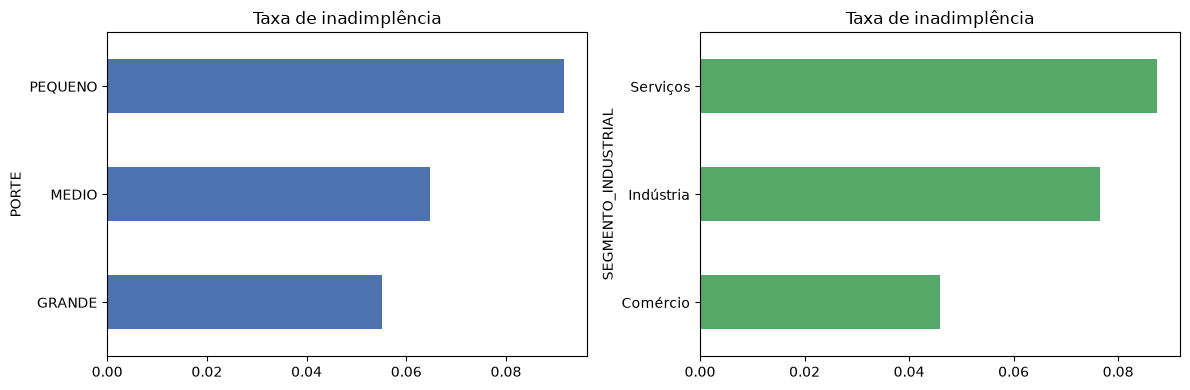

In [540]:
# Visualizando a taxa de inadimplênica por variável

fig, axes = plt.subplots(1, 2, figsize= (12,4))

df_eda.groupby('PORTE')['TARGET'].mean().sort_values().plot(kind= 'barh', ax= axes[0], color= '#4C72B0')
axes[0].set_title('Taxa de inadimplência por PORTE')
axes[0].set_title('Taxa de inadimplência')

df_eda.groupby('SEGMENTO_INDUSTRIAL')['TARGET'].mean().sort_values().plot(kind= 'barh', ax= axes[1], color= '#55A868')
axes[1].set_title('Taxa de inadimplência por SEGMENTO INDUSTRIAL')
axes[1].set_title('Taxa de inadimplência')

plt.tight_layout()
plt.show()

### 6. Analisando a correlação do `TARGET` com as colunas numéricas

O objetivo agora será **avaliar se o comportamento das variáveis (colunas) numéricas existentes nas bases de dados são de natureza linear**. Isso será importante pois servirá de argumento para credibilizar (ou descredibilizar) a adoção de um modelo de predição linear. Vou começar primeiro observando a correlação linear. 

A correlação linear das variáveis numéricas foi feita comparando 1 variável por vez com a variável `TARGET` de forma isolada, utilizando o coeficiente de *Pearson* por meio de `.corr()`, onde dado um intervalo de [-1,1]. Quanto mais próximo de zero for o indicador estatístico, menor será a correlação linear entre as variáveis numéricas candidatas à *features* e a variável `TARGET`.

In [541]:
num_cols_eda = ['VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']

correlacoes = df_eda[num_cols_eda + ['TARGET']].corr(numeric_only= True)['TARGET'].drop('TARGET')
correlacoes.sort_values(key= abs, ascending= False)

PRAZO_DIAS            0.106617
VALOR_A_PAGAR        -0.088203
RENDA_MES_ANTERIOR   -0.067847
NO_FUNCIONARIOS      -0.017179
TAXA                  0.011899
Name: TARGET, dtype: float64

- **Sobre `RENDA_MES_ANTERIOR`**

A `RENDA_MES_ANTERIOR` registrou um valor de correlação negativo e próximo de zero (-0,067). Ou seja, demonstra uma relação fraca de que **quanto maior for a renda do cliente declarada do mês anterior, menor é a tendência de inadimplência**. 

--- 

No geral, é possível entender que **as correlações lineares das variáveis numéricas são fracas quando comparadas isoladamente com a variável `TARGET`**. O que não significa que elas sejam irrelevantes para serem tratadas como *features*, mas sim que a relação com o `TARGET` provavelmente **não é linear** e/ou depende de combinações entre as variáveis *features*. Isso é um forte indício a favor da escolha de um modelo capaz de capturar não-linearidades e interações.

### 7. Analisando a tabela de quartis da variável `VALOR A PAGAR`

O `df_eda` foi divido em quartis onde cada faixa contempla 19061 cobranças, ordenados pela ordem crescente da variável `VALOR_A_PAGAR`. Depois, foi calculado a taxa de inadiplência dentro de cada grupo de forma separada. 

In [542]:
df_eda['VALOR_A_PAGAR_FAIXA'] = pd.qcut(df_eda['VALOR_A_PAGAR'], 4, duplicates= 'drop')

df_eda.groupby('VALOR_A_PAGAR_FAIXA', observed= True)['TARGET'].agg(taxa_inadimplencia= 'mean', qtd= 'count')

,taxa_inadimplencia,qtd
VALOR_A_PAGAR_FAIXA,,
"(0.099, 18765.362]",0.152301,19061
"(18765.362, 34758.695]",0.048266,19061
"(34758.695, 60933.838]",0.041026,19061
"(60933.838, 4400000.0]",0.037826,19061


Podemos ver que a inadimplência é bem mais alta na primeira faixa (valores mais baixos de `VALOR_A_PAGAR_FAIXA`) e cai de forma acentuada nas faixas seguintes, estabilizando depois. Se a relação fosse linear, esperava-se que a queda ao invés de ser abrupta, fosse mais cadenciada. **Isso se encaixa mais com um padrão de "degrau" do que uma reta em si**.

Esse é exatamente um tipo de relação que uma regressão logística simples tem dificuldade em capturar sem transformação manual, mas que um modelo baseado em árvores (como o *Gradient Boosting*) captaria com uma facilidade melhor, uma vez que esses modelos lidam melhor com a **não-linearidade** dos dados.

## Cruzamento das Bases (*Merge*)

Agora será construido o ***merge* definitivo**: a tabela que efetivamente vai ser aplicada nas seções de `Engenharia de Variáveis` e de treinamento do modelo em `Modelagem do Modelo Preditivo` (durante o treinamento do modelo).

A lógica do cruzamento de variáveis a ser aplicada é a mesma explorada na etapa de `EDA`, tendo dois pontos importantes:

1. A mesma transformação será aplicada para ambas as bases de `df_pagamentos_desenv` e `df_pagamentos_teste`. Esse ponto é essencial pois o modelo só irá funcionar corretamente se a base de teste (`df_pagamentos_desenv`) for construída sob as mesmas regras da base de treino (`df_pagamentos_desenv`).

2. (Referente ao passo 1.) Apenas `df_pagamentos_desenv` passou pela seção de `Construindo o Target`.

Os passos aplicados foram os seguintes: 

1. Preparar `df_pagamentos_teste`
2. Aplicar o *merge* definitivo
3. Validar o *merge*

### 1. Preparando `df_pagamentos_teste`

São as mesmas derivações feitas na base de desenvolvimento. Agora, serão aplicadas na base de teste. 

Como o modelo será treinado utilizando a base de `df_pagamentos_desenv` preparada, `df_pagamentos_teste` precisa ter exatamente as mesmas variáveis de entrada (*features*) que o modelo irá aprender a usar em `df_pagamentos_desenv`.

Entre outras palavras, `df_pagamentos_teste` precisa estar no formato que o modelo preditivo que será criado aprendeu se baseando em `df_pagamentos_desenv`. 

In [543]:
# convetendo as datas para o formato certo
date_cols_teste = ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']
df_pagamentos_teste[date_cols_teste] = df_pagamentos_teste[date_cols_teste].apply(pd.to_datetime)

# aplicando a regra de negócio: inadimplência
df_pagamentos_teste['PRAZO_DIAS'] = (
    df_pagamentos_teste['DATA_VENCIMENTO'] - df_pagamentos_teste['DATA_EMISSAO_DOCUMENTO']
).dt.days

# aplicando uma coluna de flag para datas suspeitas (prazos acima de 1 ano ou negativos)
df_pagamentos_teste['FLAG_DATA_SUSPEITA'] = (
    (df_pagamentos_teste['PRAZO_DIAS'] > 365) | (df_pagamentos_teste['PRAZO_DIAS'] < 0)
)

print(f'Cobranças suspeitas na base de teste: {df_pagamentos_teste['FLAG_DATA_SUSPEITA'].sum()} de {len(df_pagamentos_teste)}')

Cobranças suspeitas na base de teste: 5 de 12275


### 2. Aplicando o *merge* definitivo

Seguindo o diagrama de relacionamento do *case*, é possível extrair a cardinalidade da relação dos bancos:

- Entre `df_cadastral` e as bases de pagamentos (`df_pagamentos_desenv` e `df_pagamentos_teste`): 

**(1 para N)** -> 1 cliente no cadastro pode ter N cobranças na base de pagamentos. Nessa relação, um cliente só tem 1 cadastro, mas pode ter várias (N) cobranças ao longo do tempo.

- Entre as bases de pagamentos e `df_info`: 

**(N para 1)** -> N cobranças para 1 registro na base de info. Nessa relação, várias cobranças podem cair no mesmo mês (`SAFRA_REF`) de um mesmo cliente e todas estão sob um mesmo registro daquele mês.

---

Uma vez que está esclarecido como as bases se relacionam, é possível visualizar as chaves de junção de cada uma das tabelas e utiliza-las para realizar o *merge*. 

- Merge 1: `df_cadastral`

Cada uma das tabelas de pagamento centrais, `df_pagamentos_desenv` e `df_pagamentos_teste` serão juntas por `left join` com `df_cadastral`, onde a chave de junção usada será **`ID_CLIENTE`** (o cadastro é fixo no tempo). 

Dessa forma, as colunas de `df_cadastral` serão juntadas (`PORTE`, `SEGMENTO_INDUSTRIAL`, etc) a cada linha de pagamentos casando pela chave de junção `ID_CLIENTE`, mantendo todas as linhas de pagamento mesmo sem *match*. 

- Merge 2: `df_info`

Esse segundo *merge* é encadeado direto do resultado do primeiro *merge* com `df_cadastral`, que já tem as suas colunas agregadas e junta agora também com as colunas de `df_info` (`RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS`). Para esse *merge* as chaves de junção serão **`ID_CLIENTE`** e **`SAFRA_REF`** (info é mensal). 

---

Foi usado `how='left'` para não perder nenhuma cobrança da base de pagamentos, mesmo quando falta cadastro ou info para algum cliente/mês. Os nulos resultantes são tratados na próxima etapa (`Engenharia de Variáveis`).

In [544]:
df_final_dev = (
    df_pagamentos_desenv
    .merge(df_cadastral, on= 'ID_CLIENTE', how= 'left') # merge 1
    .merge(df_info, on= ['ID_CLIENTE', 'SAFRA_REF'], how= 'left') # merge 2
)

df_final_teste = (
    df_pagamentos_teste
    .merge(df_cadastral, on= 'ID_CLIENTE', how= 'left')
    .merge(df_info, on= ['ID_CLIENTE', 'SAFRA_REF'], how= 'left')
)

In [545]:
# shape dos dfs pós merge
print('df_final_dev:    ', df_final_dev.shape)
print('df_final_teste:  ', df_final_teste.shape)

df_final_dev:     (77414, 20)
df_final_teste:   (12275, 17)


O *merge* resulta em uma única tabela com as colunas das 3 bases, ainda com uma linha por cobrança

In [546]:
df_final_dev.columns.tolist()

['ID_CLIENTE',
 'SAFRA_REF',
 'DATA_EMISSAO_DOCUMENTO',
 'DATA_PAGAMENTO',
 'DATA_VENCIMENTO',
 'VALOR_A_PAGAR',
 'TAXA',
 'ATRASO_DIAS',
 'TARGET',
 'PRAZO_DIAS',
 'FLAG_DATA_SUSPEITA',
 'DATA_CADASTRO',
 'DDD',
 'FLAG_PF',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL',
 'PORTE',
 'CEP_2_DIG',
 'RENDA_MES_ANTERIOR',
 'NO_FUNCIONARIOS']

In [547]:
df_final_teste.columns.tolist()

['ID_CLIENTE',
 'SAFRA_REF',
 'DATA_EMISSAO_DOCUMENTO',
 'DATA_VENCIMENTO',
 'VALOR_A_PAGAR',
 'TAXA',
 'PRAZO_DIAS',
 'FLAG_DATA_SUSPEITA',
 'DATA_CADASTRO',
 'DDD',
 'FLAG_PF',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL',
 'PORTE',
 'CEP_2_DIG',
 'RENDA_MES_ANTERIOR',
 'NO_FUNCIONARIOS']

É possível visualizar que temos algumas colunas que se mantiveram em `df_final_dev` mas que não estão em `df_final_teste`: `ATRASO_DIAS`, `DATA_PAGAMENTO`, `TARGET`

In [548]:
col_comuns = df_final_dev.columns.difference(df_final_teste.columns)
print(col_comuns)

Index(['ATRASO_DIAS', 'DATA_PAGAMENTO', 'TARGET'], dtype='str')


- **Sobre `DATA_PAGAMENTO`**

Essa coluna só existe em `df_pagamentos_desenv` pois ela retrata a data dos pagamentos das cobranças já resolvidas. Logo, naturalmente não existirá essa coluna em  `df_final_teste`.

- **Sobre `ATRASO_DIAS`**

Essa coluna foi criada manualmente na seção `Construindo o Target`, onde:

`ATRASO_DIAS` = (`DATA_PAGAMENTO`-`DATA_VENCIMENTO`)

Pelo fato de `ATRASO_DIAS` depender diretamente da existência de `DATA_PAGAMENTO`, ela existará apenas na base de pagamentos de desenvolvimento. 

- **Sobre `TARGET`**

A coluna `TARGET` também é derivada de `ATRASO_DIAS` pela regra de negócio (>= 5 dias) e, portanto, não existe na base de pagamentos de teste. 

### 3. Validando o *merge*

Fazendo duas checagens para conferir a junção: 

- O número de linhas não pode mudar 
- Revisar os valores nulos introduzidos pelas bases cadastrais (`df_cadastral`) e de info (`df_info`)

#### O número de linhas não pode mudar

Conferindo nos dois *dataframes* se as linhas das cobranças não foram duplicadas com o uso do *merge*. Objetivo disso é garantir que não haja o efeito *fan-out* que poderia ser ocasionado nesse caso caso houvessem linhas duplicadas na chave de junção das tabelas "à direita" do *merge* (`df_cadastral` e `df_info`).

In [549]:
assert len(df_final_dev) == len(df_pagamentos_desenv), "Merge alterou a quantidade de linhas em df_final_dev!"
assert len(df_final_teste) == len(df_pagamentos_teste), "Merge alterou a quantidade de linhas em df_final_teste!"

print("OK: nenhuma linha duplicada ou perdida no merge.")

OK: nenhuma linha duplicada ou perdida no merge.


#### Verificando os campos *NULLs* introduzidos pelas bases `df_cadastral` e `df_info`

É preciso verificar a exisitência de valores nulos nas colunas dos da base de dados unificada para que futuramente, eles sejam tratados antes do treinamento do modelo.

Para isso, além dos valores nulos serem identificados, será extraída a taxa percentual deles por coluna para cada *dataframe*.

In [550]:
print("--- Nulos (%) em df_final_dev ---")
print((df_final_dev.isnull().mean() * 100).round(1))
print()
print("--- Nulos (%) em df_final_teste ---")
print((df_final_teste.isnull().mean() * 100).round(1))

--- Nulos (%) em df_final_dev ---
ID_CLIENTE                 0.0
SAFRA_REF                  0.0
DATA_EMISSAO_DOCUMENTO     0.0
DATA_PAGAMENTO             0.0
DATA_VENCIMENTO            0.0
VALOR_A_PAGAR              1.5
TAXA                       0.0
ATRASO_DIAS                0.0
TARGET                     0.0
PRAZO_DIAS                 0.0
FLAG_DATA_SUSPEITA         0.0
DATA_CADASTRO              0.0
DDD                        9.6
FLAG_PF                   99.7
SEGMENTO_INDUSTRIAL        1.8
DOMINIO_EMAIL              1.2
PORTE                      3.2
CEP_2_DIG                  0.0
RENDA_MES_ANTERIOR         7.9
NO_FUNCIONARIOS            9.8
dtype: float64

--- Nulos (%) em df_final_teste ---
ID_CLIENTE                 0.0
SAFRA_REF                  0.0
DATA_EMISSAO_DOCUMENTO     0.0
DATA_VENCIMENTO            0.0
VALOR_A_PAGAR              1.1
TAXA                       0.0
PRAZO_DIAS                 0.0
FLAG_DATA_SUSPEITA         0.0
DATA_CADASTRO              0.3
DDD            

É possível interpretar que o padrão de nulos é semelhante ao que já se esperava da EDA: `FLAG_PF` majoritariamente nula por natureza e valores nulos moderados em `PORTE`, `SEGMENTO_INDUSTRIAL`, `DOMINIO_EMAIL`, `RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS`. 

A base de teste apresentou um volume de nulos proporcionalmente maior em `RENDA_MES_ANTERIOR` e `NO_FUNCIONARIOS`, já que parte dos clientes de teste não possui `base_info` para os meses mais recentes. 

Isso fica registrado aqui para ser tratado (via imputação) na próxima etapa, com a mesma estratégia aplicada em ambas as bases.

## Engenharia de Variáveis (*Feature Engineering*)

Esta seção será responsável por tratar as bases de dados `df_final_dev` e `df_final_teste`, deixando elas prontas para a criação do modelo. 

Para isso, foram seguidos 5 passos descritos logo abaixo:

1. Lidar com a `FLAG_DATA_SUSPEITA`
2. Tratar os valores nulos em variáveis categóricas
3. Tratar os valores nulos em variáveis numéricas
4. Criar novas *features*
5. *Features* de histórico de comportamento do cliente

Vale mencionar que os passos foram seguidos aplicando sempre a mesma regra para ambas as bases de desenvolvimento e teste. Além disso, o que é aprendido ou decidido será olhando somente `df_final_dev` e nunca `df_final_teste`, para não gerar vazamento de dados. 

### 1. Lidando com a `FLAG_DATA_SUSPEITA`

Os casos que envolveram datas de cobranças com prazos negativos ou acima de 365 dias foram sinalizadas por `FLAG_DATA_SUSPEITA` e serão tratadas nessa análise como **erro de qualidade do dado**, ou seja, de um comportamento não real. 

A decisão do que fazer com essa coluna em cada uma das bases será diferente, e o motivo será logo explicado logo abaixo:

- **Sobre `df_final_dev`** 

Como o objetivo dessa base será de ensinar o modelo (como já mencionado anteriormente), **remover as poucas linhas que tenham essa "bandeira levantada"** (ai quais representam menos de 0,1%) evita que o modelo aprenda um padrão de risco baseado em um comportamento que não é real. 

- **Sobre `df_final_teste`**

Para essa base, **não se pode remover nenhuma linha** por exigência do *case*: a previsão precisa existir para todas as cobranças de teste, mesmo aquelas que foram sinalizadas com dado suspeito por `FLAG_DATA_SUSPEITA`.

Nesse sentido, a `FLAG_DATA_SUSPEITA` será mantida como *feature* pois com o modelo bem treinado, ele será capaz de ser cauteloso ou simplesmente ignorar quando a *flag* estiver ativa. 

In [551]:
qtd_antes = len(df_final_dev)
df_final_dev = df_final_dev[~df_final_dev['FLAG_DATA_SUSPEITA']].reset_index(drop= True)

In [552]:
print(f"Linhas removidas de df_final_dev: {qtd_antes - len(df_final_dev)}")
print(f"Shape atual de df_final_dev: {df_final_dev.shape}")
print(f"Shape atual de df_final_teste (intacto): {df_final_teste.shape}")

Linhas removidas de df_final_dev: 54
Shape atual de df_final_dev: (77360, 20)
Shape atual de df_final_teste (intacto): (12275, 17)


### 2. Tratando os valores nulos em variáveis categóricas

Tanto nessa quanto na próxima etapas serão focadas em discutir, escolher e executar estratégias de imputação para preencher os valores nulos das colunas.

---

- **Lidando com os nulos de `PORTE`, `SEGMENTO INDUSTRIAL` e `DOMINIO_EMAIL`**

Começando pelas colunas categóricas, foi possível notar anteriormente na seção de `EDA` que as cobranças com `PORTE` nulo tem possuem taxa de inadimplência bem mais alta (~17,5%) do que qualquer outra categoria preenchida. Isso indica que o **próprio fato do dado está faltando consideravelmente a informação em `PORTE` sugere que uma característica do cliente**.

Nesse sentido, ficaria inviável imputar a moda (categoria mais frequente) nos valores nulos de `PORTE`. O motivo para isso é o fato de que, ao colocar uma categoria específica para `PORTE` (MÉDIO, por exemplo), esses campos preenchidos seriam misturados e confundidos com os clientes que genuinamente são MÉDIO, o qual possui uma taxa de inadimplência bem mais baixa e não condizente com a taxa de `PORTE` quando nulo. 

Consequentemente, o modelo perderia a oportunidade aprender que o grupo de clientes sem o porte registrado possui um comportamento de risco diferente dos demais que foram registrados.

Como alternativa para tratar esses valores nulos, foi criado uma categoria própria para representar esses dados nulos chamado **`DESCONHECIDO`** que servirá não só para representar os valores *nulls* de `PORTE`, mas também de `SEGMENTO_INDUSTRIAL` e `DOMINIO_EMAIL`.

- **Lidando com `FLAG_PF`**

`FLAG_PF` atualmente só marca "X" quando a pessoa é PF ou é nula quando a pessoa é PJ. **Essa coluna será convertida para uma variável binária**, onde 1 caso seja PF e 0 caso seja PJ.

In [553]:
cat_cols_desconhecido = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL']

for df in [df_final_dev, df_final_teste]:
    df[cat_cols_desconhecido] = df[cat_cols_desconhecido].fillna('DESCONHECIDO')
    df['FLAG_PF'] = (df['FLAG_PF'] == 'X').astype(int)

In [554]:
# verificando a quantidade de valores nulos por coluna categórica nas bases
print(df_final_dev[cat_cols_desconhecido + ['FLAG_PF']].isnull().sum())
print("\n", df_final_teste[cat_cols_desconhecido + ['FLAG_PF']].isnull().sum())

PORTE                  0
SEGMENTO_INDUSTRIAL    0
DOMINIO_EMAIL          0
FLAG_PF                0
dtype: int64

 PORTE                  0
SEGMENTO_INDUSTRIAL    0
DOMINIO_EMAIL          0
FLAG_PF                0
dtype: int64


### 3. Tratando os valores nulos em variáveis numéricas

- **Qual método de imputação escolher ?**

Já para as variáveis numéricas (`RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS` e `VALOR_A_PAGAR`), o método de imputação utilizado será a **mediana**.

O motivo de utilizar ela ao invés da média se dá pelo fato de que, caso a média fosse utilizada, os *outliers* puxariam os resultados dos valores para as suas direções. 

A fim de evitar isso, escolheu-se a mediana pelo fato dela ser mais robusta aos *outliers*, pois ele ignora o valor grande do *outlier* e só olha pra posição dele na fila ordenada. Sendo esta uma alternativa melhor para registrar o "cliente típico".

---

- **A mediana será calculada apenas em `df_final_dev`**

Vale mencionar que a mediana usada para imputar precisa ser calculada usando apenas a base `df_final_dev`. Essa mesma mediana será aplicada também em `df_final_teste`. 

O intuito é simular a situação real onde não se pode ter acesso aos dados das cobranças que ainda vão acontecer. **Calcular a mediana de `df_final_teste` implicaria futuramente em um problema de vazamento de dados durante a fase de treinamento do modelo**. 

---

- **Sobre as *flags* `_NULO`**

Uma flag `_NULO` foi criada para cada uma das colunas numéricas (Exemplo: `RENDA_MES_ANTERIOR` possui `RENDA_MES_ANTERIOR`). O objetivo dessa coluna é avisar que o valor daquele campo foi imputado e que antes era um valor nulo. 

Isso foi uma forma encontrada de avisar e, consequentemente, fazer com que o modelo perceba que aquele valor foi imputado e não é um dado real. 

In [555]:
num_cols_imputar = ['RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'VALOR_A_PAGAR']
medianas_dev = df_final_dev[num_cols_imputar].median()

print(f"Medianas calculadas em df_final_dev (usadas para imputar as duas bases)")
print(medianas_dev)

Medianas calculadas em df_final_dev (usadas para imputar as duas bases)
RENDA_MES_ANTERIOR    240502.00
NO_FUNCIONARIOS          118.00
VALOR_A_PAGAR          34749.55
dtype: float64


In [556]:
# adicionando os valores para cada coluna de cada df
for df in [df_final_dev, df_final_teste]:
    for col in num_cols_imputar:
        df[f'{col}_NULO'] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(medianas_dev[col])

### 4. Criando novas *features*

Foram criadas duas novas *features* que serão importantes para análise das cobranças.

- **`MES_VENCIMENTO`**

Essa coluna extrai o mês de vencimento de `DATA_VENCIMENTO`. O intuito é detectar se existem períodos específicos do ano que ocorrem mais ou menos atrasos, etc. Entre outras palavras, facilitar a análise de **sazonalidade dos vencimentos**.

É uma forma melhor de detectar os padrões ao invés de somente utilizar `DATA_VENCIMENTO` pois o modelo ter "em mãos" apenas o mês do vencimento permite que ele seja capaz de agrupar as cobranças de meses iguais entre os anos diferentes, podendo assim captar um padrão mais recorrente. 

- **`RAZAO_VALOR_VENDA`**

Essa coluna será definida pela razão entre outras duas colunas: 

`RAZAO_VALOR_VENDA` = `VALOR_A_PAGAR` / `RENDA_MES_ANTERIOR`

Trata-se da razão do valor a ser pago e da renda do cliente do mês anterior. Ou seja, essa *feature* mede o quão "pesada" é a cobrança em relação à capacidade financeira do cliente naquele mês. 

Em casos de `RENDA_MES_ANTERIOR = 0`, onde seria uma divisão por zero. O valor é substituido por um resultado nulo e depois a mediana da própria razão calculada em `df_final_dev` é imputada.

In [557]:
# aplicando as novas features nas duas bases
for df in [df_final_dev, df_final_teste]:
    df['MES_VENCIMENTO'] = df['DATA_VENCIMENTO'].dt.month
    df['RAZAO_VALOR_RENDA'] = df['VALOR_A_PAGAR'] / df['RENDA_MES_ANTERIOR'].replace(0, np.nan)

# mediana para a razão
mediana_razao = df_final_dev['RAZAO_VALOR_RENDA'].median()

# corrigindo os casos onde RENDA_MES_ANTERIOR = 0
for df in [df_final_dev, df_final_teste]:
    df['RAZAO_VALOR_RENDA'] = df['RAZAO_VALOR_RENDA'].fillna(mediana_razao)

In [558]:
# as novas features
df_final_dev[['MES_VENCIMENTO', 'RAZAO_VALOR_RENDA']].describe()

,MES_VENCIMENTO,RAZAO_VALOR_RENDA
count,77360.000000,7.736000e+04
mean,6.474573,4.060573e-01
std,3.526687,4.911980e+00
min,1.000000,9.168424e-07
25%,3.000000,6.907870e-02
50%,6.000000,1.477629e-01
75%,10.000000,3.228267e-01
max,12.000000,6.831219e+02


### 5. *Features* de histórico de comportamento do cliente

O objetivo agora foi para analisar as cobranças que cada cliente tem no decorrer do tempo para referenciar a taxa de inadimplência do mesmo.

Para isso, foi necessário criar *features* que representassem o comportamento passado do cliente no momento exato da cada cobrança: 

- Quantas cobranças esse cliente já fez antes dessa
- Que porcentagem delas atrasaram
- Qual foi, em média, o tamanho do atraso (em dias) 

#### 5.1. Ordenando os dados por cliente e data 

Primeiramente, será necessário reorganizar a ordem de toda a tabela para que, dentro de cada clinete, as cobranças fiquem em ordem cronológica (i.e. da cobrança mais antiga para a mais recente). 

In [559]:
df_final_dev = df_final_dev.sort_values(['ID_CLIENTE','DATA_VENCIMENTO']).reset_index(drop= True)

#### 5.2. Quantidade de cobranças anteriores 

O objetivo aqui é contabilizar a quantidade de cobranças anteriores por grupos de clientes utilizando `cumcount()`.

Nesse sentido, a primeira cobrança de cada cliente começa em zero (por que não houve nenhuma cobrança anteiror) e vai acumulando em +1 a medida que aumentam as quantidade de cobranças no decorrer do tempo (já que as datas já estão organizadas em ordem cronológica por cliente).

In [560]:
grupo_cliente = df_final_dev.groupby('ID_CLIENTE')
df_final_dev['QTD_COBRANCAS_ANTERIORES'] = grupo_cliente.cumcount()

#### 5.3. Deslocando o `TARGET`

1. Com o `.shift()`, ele pega a coluna `TARGET` de cada cliente e joga uma linha para baixo. Ou seja, na linha de cobrança 2 do cliente, vai aparecer o `TARGET` da linha 1 e por aí vai. Vale mencionar que na primeira linha de cobrança de cada cliente, o `.shift()` coloca um vazio (*NaN*).

O objetivo dessa parte é fazer com que, quando ocorra a soma dos valores, **a linha atual nunca inclua o valor do próprio resultado dela mesma, apenas os resultados que vinheram antes**, para evitar *data leakage*.

2. Depois disso, os valores deslocados são somados, linha a linha. O objetivo dessa soma é **contar quantas das cobranças anteriores foram inadimplentes**.

3. Depois disso, a soma de inadimplencia anterior é dividada pela quantidade ed cobranças anteriores para entregar uma razão que expressa a proporção percentual de vezes que o cliente atrasou no passado (`PCT_INADIMPLENCIA_ANTERIOR`).

Vale mencionar que essa proporção foi calculada de forma progressiva, atualizando a cada nova cobrança e sempre olhando só para o passado. Além disso, também foi calculada a proporção percentual da mesma forma para o atraso médio anterior (`ATRASO_MEDIO_ANTERIOR`).

In [561]:
target_deslocado = grupo_cliente['TARGET'].shift()
atraso_deslocado = grupo_cliente['ATRASO_DIAS'].shift()

soma_inadimplencia_anterior = target_deslocado.groupby(df_final_dev['ID_CLIENTE']).cumsum()
soma_atraso_anterior = atraso_deslocado.groupby(df_final_dev['ID_CLIENTE']).cumsum()

df_final_dev['PCT_INADIMPLENCIA_ANTERIOR'] = (
    soma_inadimplencia_anterior / df_final_dev['QTD_COBRANCAS_ANTERIORES'].replace(0,np.nan)
)

df_final_dev['ATRASO_MEDIO_ANTERIOR'] = (
    soma_inadimplencia_anterior / df_final_dev['QTD_COBRANCAS_ANTERIORES'].replace(0,np.nan)
)

df_final_dev[['ID_CLIENTE', 'DATA_VENCIMENTO', 'TARGET', 'QTD_COBRANCAS_ANTERIORES', 'PCT_INADIMPLENCIA_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR']].head(8)

,ID_CLIENTE,DATA_VENCIMENTO,TARGET,QTD_COBRANCAS_ANTERIORES,PCT_INADIMPLENCIA_ANTERIOR,ATRASO_MEDIO_ANTERIOR
0,8784237149961904,2018-09-04,0,0,NaN,NaN
1,8784237149961904,2018-09-10,0,1,0.0,0.0
2,8784237149961904,2018-09-10,0,2,0.0,0.0
3,8784237149961904,2018-09-11,0,3,0.0,0.0
4,8784237149961904,2018-09-11,0,4,0.0,0.0
5,8784237149961904,2018-09-24,0,5,0.0,0.0
6,8784237149961904,2018-09-24,0,6,0.0,0.0
7,8784237149961904,2018-09-25,0,7,0.0,0.0


Observando a primeira linha do cliente `8784237149961904`, especificamente as colunas `PCT_INACIMPLENCIA_ANTERIOR` e `ATRASO_MEDIO_ANTERIOR` aparecem como *NaN* indicando que não existe passado nenhum para calcular uma taxa.

Esses dados vazios serão tratados posteriormente com uma imputação por média:

- Taxa média do *target* para `PCT_INADIMPLENCIA_ANTERIOR`
- Taxa média dos dias de atraso para `ATRASO_MEDIO_ANTERIOR`

#### 5.4. Tratando o caso sem histórico

Foi criada uma flag `CLIENTE_SEM_HISTORICO` focada para marcar as cobranças sem histórico (as das primeiras linhas por cliente). Essa necessidade vem pelo fato de que é preciso encontrar alguma forma de **preservar o sinal**, no sentido de que o modelo precisa saber que aquela linha de cobrança do cliente não possui um histórico anterior. 

Falando mais sobre o **tratamento da variável vazia**, assumi que na ausência do histórico de cada cliente, esse cliente se comporta como a média de todo mundo. Ou seja, a imputação nos campos *NaN* foi por meio da **média**. 

In [562]:
df_final_dev['CLIENTE_SEM_HISTORICO'] = (df_final_dev['QTD_COBRANCAS_ANTERIORES'] == 0).astype(int)

media_geral_target = df_final_dev['TARGET'].mean()
media_geral_atraso = df_final_dev['ATRASO_DIAS'].mean()

df_final_dev['PCT_INADIMPLENCIA_ANTERIOR'] = df_final_dev['PCT_INADIMPLENCIA_ANTERIOR'].fillna(media_geral_target)
df_final_dev['ATRASO_MEDIO_ANTERIOR'] = df_final_dev['ATRASO_MEDIO_ANTERIOR'].fillna(media_geral_atraso)

print("Clientes na 1ª cobrança (sem histórico):", df_final_dev['CLIENTE_SEM_HISTORICO'].sum())
print("Valor de preenchimento (média geral do TARGET):", round(media_geral_target, 4))

Clientes na 1ª cobrança (sem histórico): 1247
Valor de preenchimento (média geral do TARGET): 0.0698


#### 5.5. Replicando para a base teste `df_final_teste`

Como todas as safras de `df_final_dev` (até 2021-06) são anteriores a todas as safras de `df_final_teste` (a partir de 2021-07). Logo, é possível interpretar que:

**O histórico de cobranças anterior de qualquer cliente de teste é, por definição, todo o histórico dele em df_final_dev**.

Ou seja, não precisa aplicar a lógica de deslocamento de variáveis aqui por que **não existe o risco da base de dados de teste olhar para o futuro pois ele ainda não existe**. 

Ao invés disso, dá para facilitar as coisas e usar todo o histórico do cliente em `df_final_teste` por meio de `QTD_COBRANCAS_ANTERIORES`, `PCT_INADIMPLENCIA_ANTERIOR` e `ATRASO_MEDIO_ANTERIOR`. 

Depois disso, é feito o **tratamento dos clientes novos**: aqueles que apareceram em `df_final_teste` que nunca apareceram em `df_final_dev`. Para esses clientes, eles recebem a flag `CLIENTE_SEM_HISTORICO = 1` e o mesmo preenchimento pela média geral

In [563]:
historico_por_cliente = df_final_dev.groupby('ID_CLIENTE').agg(
    QTD_COBRANCAS_ANTERIORES=('TARGET', 'size'),
    PCT_INADIMPLENCIA_ANTERIOR=('TARGET', 'mean'),
    ATRASO_MEDIO_ANTERIOR=('ATRASO_DIAS', 'mean'),
).reset_index()

df_final_teste = df_final_teste.merge(historico_por_cliente, on='ID_CLIENTE', how='left')

# Clientes de teste que nunca apareceram em df_final_dev: sem histórico algum
df_final_teste['CLIENTE_SEM_HISTORICO'] = df_final_teste['QTD_COBRANCAS_ANTERIORES'].isnull().astype(int)

df_final_teste['QTD_COBRANCAS_ANTERIORES'] = df_final_teste['QTD_COBRANCAS_ANTERIORES'].fillna(0)
df_final_teste['PCT_INADIMPLENCIA_ANTERIOR'] = df_final_teste['PCT_INADIMPLENCIA_ANTERIOR'].fillna(media_geral_target)
df_final_teste['ATRASO_MEDIO_ANTERIOR'] = df_final_teste['ATRASO_MEDIO_ANTERIOR'].fillna(media_geral_atraso)

print("Clientes de teste sem nenhum histórico em dev:", df_final_teste['CLIENTE_SEM_HISTORICO'].sum(), "de", len(df_final_teste))

Clientes de teste sem nenhum histórico em dev: 228 de 12275


No final dessa seção, `df_final_dev`e `df_final_teste` devem possuir o mesmo conjunto de colunas candidatas à *features*, com exceção de `DATA_PAGAMENTO`, `ATRASO_DIAS` e `TARGET`, que são exclusivas da base de dados dev. 

Além disso, os nulos remanescentes foram tratados, novas *features* fora criadas e o histórico de comportamento do cliente foi construído sem vazamento de dados. 

## *Split* Treino x Validação

Nessa etapa ocorrerá **a divisão do conjunto de dados**: uma parte será do conjunto de dados será dedicado ao treino do modelo e a outra parte será dedicada à validação do mesmo. 

Como já mencionado anteriormente, essa divisão será feita tendo como base a ordem cronológica das safras, simulando a situação real de que o modelo treinará com os dados do passado e irá ser validado com os dados de um período ainda não visto por ele. Só depois disso, o modelo será aplicado em `df_final_teste`.

Além da divisão do conjunto de dados, serão selecionadas as variáveis *features* (X) e a (y) para o modelo.

---

- *Split* dos dados por data 

`df_final_dev` cobre as safras de 2018-08 a 2021-6. A data que foi escolhida como corte foi **2021-01**: onde safras anteriores irão fazer parte do conjunto de dados de treino e as 6 últimas safras (2021-01 a 2021-6) irã fazer parte do conjunto de dados de validação.  

Existem dois motivos para esta data ter sido escolhida como data de corte:

1. Na proporção de dados entre treino | validação, na maioria dos projetos é de 80/20. Nessa data de corte, ela deixa o conjunto de dados de validação com aproximadamente 18% da base.

2. A data de 2021-01 é o período que antecede o início da base de teste `df_final_teste` (que começa em 2021-07).

In [564]:
SAFRA_CORTE = '2021-01'

#adicionando a variável de corte
df_final_dev['SAFRA_REF_DT'] = pd.to_datetime(df_final_dev['SAFRA_REF'])

#splitando a base de dados de dev
treino = df_final_dev[df_final_dev['SAFRA_REF_DT'] < SAFRA_CORTE].copy()
validacao = df_final_dev[df_final_dev['SAFRA_REF_DT'] >= SAFRA_CORTE].copy()

In [565]:
print(f"Treino: {treino.shape} | safras {treino['SAFRA_REF'].min()} a {treino['SAFRA_REF'].max()}")
print(f"Validação: {validacao.shape} | safras {validacao['SAFRA_REF'].min()} a {validacao['SAFRA_REF'].max()}")
print(f"\nProporção validação: {len(validacao) / len(df_final_dev):.1%}")

Treino: (63103, 30) | safras 2018-08 a 2020-12
Validação: (14257, 30) | safras 2021-01 a 2021-06

Proporção validação: 18.4%


### Verificando a taxa de inadimplência entre as bases de treino e validação

Esse parte vai ser apenas uma checagem para conferir se a taxa de inadimplência está parecida entre o treino e a validação. 

In [566]:
print(f"Taxa de inadimplência - Treino: {treino['TARGET'].mean():.2%}")
print(f"Taxa de inadimplência - Validação: {validacao['TARGET'].mean():.2%}")

Taxa de inadimplência - Treino: 7.15%
Taxa de inadimplência - Validação: 6.26%


É possível visualizar que as taxas ficaram próximas, o que pode ser interpretado como positivo pois mostra que a divisão da base não introduziu um desiquilíbrio artificial da taxa entre os dois grupos.

Como foi visto anteriormente na etapa de `EDA`, o período de fev-mar/2020 (supostamente ligado ao início da pandemia) teve uma taxa bem mais alta que a média, mas esse período caiu inteiramente dentro do treino neste corte, então não deve distorcer a leitura das métricas de validação.

### Selecionando as colunas de *features* e *target*

Agora **as colunas de *features* e a de *target* serão separadas** para representar as entradas e o rótulo do modelo a ser criado na próxima etapa. 

Vale mencionar que **algumas colunas serão excluídas** no processo: identificadores, datas brutas e colunas que não existem na base de teste (`ATRASO_DIAS`, `TARGET`, `DATA_PAGAMENTO`) serão excluídas.

In [567]:
features_numericas = [
    'VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
    'MES_VENCIMENTO', 'RAZAO_VALOR_RENDA',
    'QTD_COBRANCAS_ANTERIORES', 'PCT_INADIMPLENCIA_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR',
    'RENDA_MES_ANTERIOR_NULO', 'NO_FUNCIONARIOS_NULO', 'VALOR_A_PAGAR_NULO',
    'FLAG_PF', 'CLIENTE_SEM_HISTORICO', 'FLAG_DATA_SUSPEITA',
]

features_categoricas = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL']
features = features_numericas + features_categoricas 


In [568]:
X_treino, y_treino = treino[features], treino['TARGET']
X_validacao, y_validacao = validacao[features], validacao['TARGET']

print(f"Total de features: {len(features)}")
print(f"X_treino: {X_treino.shape} | X_validacao: {X_validacao.shape}")

Total de features: 19
X_treino: (63103, 19) | X_validacao: (14257, 19)


## Modelagem do Modelo Preditivo

Para essa etapa, foram treinados dois modelos em `X_treino`/`y_treino`, para que sejam comparados na seção de `Métricas Estatísticas`. Os modelos treinados foram:

1. **Regressão Logística**
2. **Gradient Boosting**

---

As observações abaixo são aplicadas para ambos os modelos:

- **Observação 1**: A importância do balanceamento de classes com `class_weights= 'balanced'`

A fim de evitar que o modelo seja enviesado por conta da distribuição desbalanceada da variável `TARGET` (~93%/7%), haverá um balanceamento da classe no sentido de que, quando um *target* for pertencente à classe minoritária, essa classe receberá um peso maior na hora do treinamento para que o modelo não aprenda apenas as situações da classe majoritária de 93%. 

- **Observação 2**: Reprodutibilidade 

Por motivos de reprodutibilidade, deixarei `random_state= 42` para que os valores randômicos gerados na criação do modelo sejam reproduzidos de forma igual em outras máquinas além da minha máquina local. 

### 1. Modelo de Regressão Logística

- **Motivo de Escolha**

Inicialmente, pensei em desenvolver um modelo de regressão linear como modelo básico para servir de comparação com o *gradient boosting*. Com tudo, percebi que o melhor modelo para utilizar como base e que representa melhor o contexto do problema seria o modelo de **regressão logística**.

O motivo para isso se deu por conta da natureza do problema: **A saída do meu modelo precisa ser obrigatóriamente um valor entre 0 e 1 para poder representar a probabilidade de inadimplência.**

Ou seja, para que o valor de saída seja entre 0 e 1, a **função sigmoide**, que vem imbutida na regressão logística, irá "achatar" os valores, deixando aqueles valores negativos ou acima de 1 dentro do intervalo desejado para que, posteriormente, seja possível retornar a probabilidade de inadimplência a partir dele. 

Além disso, o modelo de regressão logística é conhecido por **lidar bem com problemas de classificação binária** (que é esse caso) e problemas de multiclassificação.

---

Pelo fato do modelo exigir que todas as variáveis sejam numéricas e, idealmente na mesma escala, é preciso usar um *pipeline* que aplica as seguintes funções:

- **`OneHotEncoder`**

Essa função é aplicada nas colunas categóricas, transformando cada categoria em uma coluna binária de 0 ou 1. 

- **`StandardScaler`** 

Essa função é aplicada com o objetivo de padronizar a escala dos números das colunas. O objetivo é evitar que magnitudes muito elásticas (i.e. altas demais ou baixas demais) impactem negativamente na aprendizagem do modelo. 

É possível exemplificar a importância da padronização da escala ao olhar para *features* como `VALOR_A_PAGAR` que está na casa de milhares e a `MES_VENCIMENTO` que vai de 1 até 12.

---

A modelagem ocorrerá da seguinte forma:

1. Transformando as variáveis categóricas e numéricas 
2. Fazendo o pipeline de criação do modelo 
3. Treinando o modelo.

In [569]:
preprocessador_logreg =ColumnTransformer([
    ('num', StandardScaler(), features_numericas),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), features_categoricas),
])

modelo_logreg = Pipeline([
    ('preprocessador', preprocessador_logreg),
    ('classificador', LogisticRegression(max_iter= 1000, class_weight= 'balanced', random_state= 42)),
])

modelo_logreg.fit(X_treino, y_treino)
print("Modelo de Regressão Logística treinado.")

Modelo de Regressão Logística treinado.


### 2. Modelo Gradient Boosting

- **Motivo da Escolha**

Esse modelo servirá como contraponto do modelo base (modelo de regressão lógica) e será utilizado como comparativo na próxima seção para definir qual é o melhor.

O motivo que eu escolhi esse modelo vem das minhas suspeitas que tive na seção de `EDA`, onde lá foi mostrado que as variáveis numéricas têm relação fraca e não-linear com o *target* de forma isolada, além do efeito de "degrau" visto ao relacionar `VALOR_A_PAGAR` com a taxa de inadimplência.

Nesse sentido, caso o modelo base de regressão lógica não consiga render bons resultados, minha suspeita seria de que fosse por conta da natureza pouco linear dos dados, fazendo com que o modelo de contraponto (modelo de *gradient boosting*) seja uma boa alternativa. 

---

- **Não há necessidade de pré-processamento** 

Diferentemente do primeiro modelo, o `HistGradientBoostingClassifier` consegue lidar nativamente com as variáveis categóricas usando `categorical_features= 'from_dtype'`, onde ele detecta automaticamente quais colunas tratar como categóricas.

Além disso, não precisa de uma padronização da escala para as variáveis numéricas uma vez que, pelo fato do modelo se basear em árvores de decisões, o treinamento se dá por comparações do que efetivamente operações com os pesos. 

---

A modelagem seguirá da seguinte forma: 

1. Criar uma variável que armazena o conjunto de treino e define as features categoricas
2. Definir o modelo 
3. Treinar o modelo 

In [570]:
X_treino_gb = X_treino.copy()
X_treino_gb[features_categoricas] = X_treino_gb[features_categoricas].astype('category')

modelo_gb = HistGradientBoostingClassifier(
    categorical_features= 'from_dtype',
    class_weight= 'balanced',
    random_state= 42,
)

modelo_gb.fit(X_treino_gb, y_treino)
print("Modelo Gradient Boosting treinado.")

Modelo Gradient Boosting treinado.


No final dessa seção, os dois modelos foram treinados na base de treino (safras até 2020-12). A seguir, o modelo será aplicado em `X_validacao` e será comparado o desempenho com as métricas ROC-AUC e Brier Score, para qual modelo adotar como definitivo. 

## Métricas Estatísticas (Validação do Modelo)

Nessa seção, serão aplicadas as métricas estatísticas para avaliar o desempenho do modelo. O objetivo final daqui será escolher qual será o melhor modelo a ser aplicado em `base_pagamentos_teste`, discutindo os resultados das estatísticas e explicando o por que que tais métricas foram adotadas. 

Os dois modelos treinados serão aplicados em `X_validacao`, onde nenhum dos dois acessou essa parte do conjunto de dados durante o treino. 

---

Para comparar o desempenho entre eles, foram utilizadas duas métricas:

- **ROC-AUC**

Essa métrica mede a capacidade do modelo discriminar o resultado do modelo. Ele dá probabilidades mais altas para quem realmente ficou inadimplente do que para quem não ficou, variando de 0,5 (equivale à um chute aleatório) até 1,0 (discriminação perfeita). 

Essa análise é feita com relação à curva ROC, tendo como base a taxa de falsos positivos (dentre todos os casos que realmente eram adimplentes, quantos o modelo classificou errado como inadimplentes) no eixo X e a taxa de verdadeiros positivos (dentre todos os casos que eram inadimplentes, quantos o modelo identificou corretamente) no eixo Y. 

O motivo de eu ter escolhido essa métrica para discriminar o desempenho do modelo ao invés de métricas mais conhecidas como acurácia, precisão, *f1-score*, *recall*, dentre outras, se deu por que elas são calculadas sobre a versão binária do modelo. Para isso, eu teria que aplicar um corte para dividir as duas classes e, consequentemente, **transformar a saída do modelo na predição de classes de inadimplência e não em uma porcentagem de inadimplência** (como exige o *case*).

- **Brier Score**

Essa métrica será responsável por identificar o quão calibradas estão saindo as probabilidades do modelo, indicando a diferença quadrática média entre a probabilidade prevista e o resultado real (0 ou 1). Dessa forma, quanto mais perto de 0 será melhor, indicando que as probabilidades, em média, estavam condizentes sobre o que de fato aconteceu. É uma boa métrica para analisar já que a entrega final já é uma probabilidade e não uma classificação.

In [571]:
# Regressão Logística
proba_logreg = modelo_logreg.predict_proba(X_validacao)[:,1]

# Gradient Boosting
X_validacao_gb = X_validacao.copy()
X_validacao_gb[features_categoricas] = X_validacao_gb[features_categoricas].astype('category')
proba_gb = modelo_gb.predict_proba(X_validacao_gb)[:,1]

In [572]:
# Passando os resultados para um df
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Gradient Boosting'],
    'ROC-AUC': [
        roc_auc_score(y_validacao, proba_logreg),
        roc_auc_score(y_validacao, proba_gb)
    ],
    'Brier Score': [
        brier_score_loss(y_validacao, proba_logreg),
        brier_score_loss(y_validacao, proba_gb)
    ]
})

In [573]:
# visualizando
resultados

,Modelo,ROC-AUC,Brier Score
0,Regressão Logística,0.907656,0.128515
1,Gradient Boosting,0.933196,0.103783


Com as métricas calculadas, é possível ver que o modelo de *Gradient Boosting* é sutilmente melhor do que o de Regressão Logística pois:

- **AUC de *Grandient Boosting* > AUC de Regressão Logística**: 0,936 vs 0,912, com diferença de 0,024

- ***Brier Score* de *Gradient Boosting* < *Brier Score* de *Regressão Logística***: 0,102 vs 0,124, com diferença de 0,022

Complementando a análise da métrica de ROC-AUC,  a curva ROC mostra mostra que para cada possível ponto de corte, uma relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos, onde **quanto mais a curva se aproxima de 1, melhor é a discriminação do modelo**. 

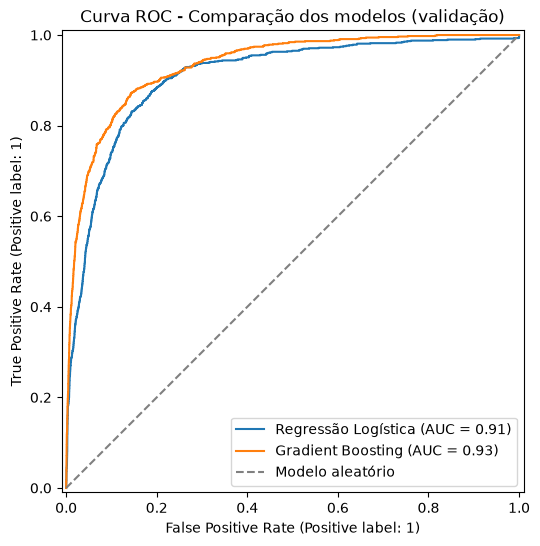

In [574]:
# plotando as curvas ROC

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_validacao, proba_logreg, name='Regressão Logística', ax=ax)
RocCurveDisplay.from_predictions(y_validacao, proba_gb, name='Gradient Boosting', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatório')
ax.set_title('Curva ROC - Comparação dos modelos (validação)')
ax.legend()
plt.show()

É possível visualizar que as duas tiveram resultados parecidos, com uma leve superioridade para a curva do modelo de *Gradient Boosting* pois no gráfico, é possível visualizar que ele fica visivelmente um pouco mais "puxado" para cima e para esquerda que a regressão logística. Indicando um valor um pouco melhor da  (Área sob a linha da curva) do que o modelo de Regressão logística. Consequentemente é possível interpretar que **o modelo *Gradient Boosting* possui uma capacidade levemente melhor de descriminar (i.e. separar e distinguir) as duas classes de inadimplência**. 

### Visualizando a curva de calibração 

Esse gráfico agrupa as previsões em faixas de probabilidade e compara a probabilidade média prevista com a taxa real de inadimplência observada em cada faixa. Quanto mais próxima a curva estiver da diagonal (linha pontilhada), mais calibradas estão as probabilidades. 

Logo, quando o modelo diz "20% de chance", isso realmente deveria acontecer em ~20% dos casos da base de dados, entregando confiabilidade para as métricas extraídas do modelo. 

---

Essa comparação será importante devido ao fato das métricas extraídas dos dois modelos serem próximas. A curva de calibração será o fator que irá determinar um nível de discrepência significativo entre os modelo, o suficiente para conseguir determinar qual deles será o modelo final. 

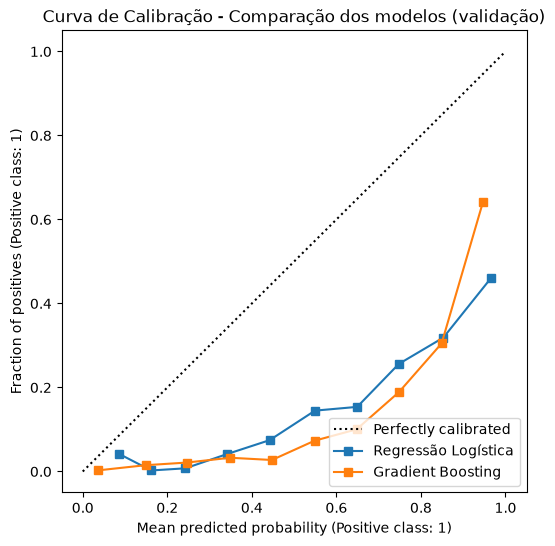

In [575]:
# plotando as curvas de calibração
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(y_validacao, proba_logreg, n_bins=10, name='Regressão Logística', ax=ax)
CalibrationDisplay.from_predictions(y_validacao, proba_gb, n_bins=10, name='Gradient Boosting', ax=ax)
ax.set_title('Curva de Calibração - Comparação dos modelos (validação)')
plt.show()

Ao visualizar as curvas, é possível visualizar que a melhor se aproxima do cenário de perfeitamente calibrado (*Perfectly calibrated*) é a curva do *Gradient Boosting*.

Podemos concluir que o Gradiente Boosting supera a Regressão logística nas duas métricas: maior ROC-AUC (menor discriminação entre clientes que vão e não vão atrasar) e menor Brier Score (probabilidades mais próximas da realidade observada), com uma calibragem bem mais acentuada para o modelo de *Gradient Boosting*.

Isso confirma as suspeitas que a análise exploratória feita e `EDA` já apontava: as relações não-lineares e possíveis interações entre variáveis *features* favorecem um modelo baseado em árvores. E portanto:

- **Modelo final adotado: *Gradient Boosting***

## Aplicando o Modelo em `base_pagamentos_teste`

Por fim, com o modelo definido, resta aplicar ele em `base_pagamentos_teste` é obter os resultados. Para isso, será necessário:

1. Retreinar o modelo com todos os dados de `df_final_dev` (treino +validação juntos)

2. Aplicar o modelo *Gradient Boosting* em `df_final_teste`

3. Fazer uma checagem dos resultados aplicados em `df_final_teste`

4. Montar e salvar o arquivo final à ser enviado para a submissão do *case*: `submissao_case.csv`

### 1. Retreinando o modelo final com `df_final_dev` completo

A divisão do conjunto de dados de `df_final_dev` já cumpriu o papel: comparar os modelos de forma justa.

Uma vez que o modelo definitivo foi escolhido, não faz sentido continuar reservando apenas cerca de 18% dos dados sem usá-los no modelo que vai gerar a entrega final. Nesse sentido, principal motivo para o retreino do modelo na base completa se dá pelo fato de que, com mais dados, o modelo tende à gerar um resultado ligeiramente melhor. 

In [576]:
# separando as features da base de dev e o target
X_final_dev = df_final_dev[features].copy()
X_final_dev[features_categoricas] = X_final_dev[features_categoricas].astype('category')
y_final_dev = df_final_dev['TARGET']

# retreinando do modelo de gradient boosting
modelo_final = HistGradientBoostingClassifier(
    categorical_features='from_dtype',
    class_weight='balanced',
    random_state=42,
)
modelo_final.fit(X_final_dev, y_final_dev)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


### 2. Aplicando o modelo *Gradient Boosting* em `df_final_teste`

In [577]:
# separando as features da base de teste
X_final_teste = df_final_teste[features].copy()
X_final_teste[features_categoricas] = X_final_teste[features_categoricas].astype('category')

# aplicando o modelo e jogando os valores em uma nova coluna na base de teste
df_final_teste['PROBABILIDADE_INADIMPLENCIA'] = modelo_final.predict_proba(X_final_teste)[:, 1]

In [578]:
df_final_teste['PROBABILIDADE_INADIMPLENCIA'].describe()

count    12275.000000
mean         0.139648
std          0.234817
min          0.002162
25%          0.013882
50%          0.030266
75%          0.127429
max          0.989077
Name: PROBABILIDADE_INADIMPLENCIA, dtype: float64

### 3. Checagem dos resultados aplicados em `df_final_teste`

Aqui estão algumas verificações estabelcidas pós implementação do modelo na base de testes:

1. **Verificar se os valores de `PROBABILIDADE_INADIMPLENCIA`**: A coluna expressa uma probabilidade, logo, os valores precisam estar entre 0 e 1. 

2. **Verificar se existem valores nulos**: Não podem haver valores nulos em `PROBABILIDADE_INADIMPLENCIA`. Todos os clientes existentes na base precisam ter uma probabilidade de inadimplência associada.

3. **Verificar a quantidade de linhas**: A quantidade de linhas precisa se a mesma da base de teste original. Cada cliente da base precisa ter a sua respectiva probabilidade de inadimplência.

In [579]:
assert df_final_teste['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all(), "Existem probabilidades fora do intervalo [0, 1]!"
assert df_final_teste['PROBABILIDADE_INADIMPLENCIA'].isnull().sum() == 0, "Existem probabilidades nulas!"
assert len(df_final_teste) == 12275, "Quantidade de linhas não bate com a base de teste original!"

print("Fim das verificações")

Fim das verificações


### 4. Montando e salvando `submissao_case.csv`

In [580]:
# separando apenas as colunas especificadas pelo case
submissao = df_final_teste[['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA']].copy()

print(submissao.shape)
submissao.head()

(12275, 3)


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.088023
1,274692171162531764,2021-07,0.114129
2,274692171162531764,2021-07,0.152188
3,274692171162531764,2021-07,0.152188
4,465309249432033993,2021-07,0.021490


In [581]:
# salvando
submissao.to_csv('submissao_case.csv', index= False)
print("Arquivo 'submissao_case.csv' gerado com sucesso.")

Arquivo 'submissao_case.csv' gerado com sucesso.


## Referências

### Sobre os *merges* realizados nas seções de `Cruzamento das Bases` e `EDA`

- https://pandas-pydata-org.translate.goog/docs/user_guide/merging.html?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://pandas-pydata-org.translate.goog/docs/reference/api/pandas.merge.html?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc

### Sobre o treinamento do modelo na seção de `Modelagem do Modelo Preditivo`

- https://medium.com/@nara.guimaraes/regress%C3%A3o-log%C3%ADstica-como-usu%C3%A1-la-em-an%C3%A1lise-de-dados-3fdb6be3a255
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

### Sobre as métricas utilizadas na seção de `Métricas`

- https://www.datacamp.com/pt/tutorial/auc
- https://h2o-ai.translate.goog/wiki/auc-roc/?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.metrics.brier_score_loss.html?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc

## 